In [8]:
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

In [9]:
df = pd.read_csv("posts_vk.csv")
print(df.shape)
df.head()

(39690, 22)


,domain,owner_id,post_id,post_key,from_id,dt_msk,edited_dt_msk,text,views,likes,comments,reposts,reactions_total,is_pinned,marked_as_ads,is_donut,post_source_type,post_type,n_photos,cover_photo_url,all_photo_urls,post_url
0,literabook,-33874468,953135,-33874468_953135,-33874468,2026-04-02 11:33:58+03:00,NaN,"Интимнее, чем секс \nВсякий раз, когда мы гово...",31453,66,2,60,66.0,0,0,0,api,post,1,https://sun9-26.userapi.com/s/v1/ig2/N24sE2iTm...,"[""https://sun9-26.userapi.com/s/v1/ig2/N24sE2i...",https://vk.com/wall-33874468_953135
1,literabook,-33874468,953106,-33874468_953106,-33874468,2026-04-02 10:22:39+03:00,NaN,«В Япoнии тяжело быть жeной глaвы меcтной адми...,88292,612,9,301,612.0,0,0,0,api,post,1,https://sun9-65.userapi.com/s/v1/ig2/IWxPKVhWS...,"[""https://sun9-65.userapi.com/s/v1/ig2/IWxPKVh...",https://vk.com/wall-33874468_953106
2,literabook,-33874468,953054,-33874468_953054,-33874468,2026-04-02 08:46:20+03:00,NaN,Запомни три правила. ☝️☝️☝️\n \nПервое. Если т...,85588,323,4,151,323.0,0,0,0,api,post,2,https://sun1-94.userapi.com/s/v1/ig2/6tkrGWgDb...,"[""https://sun1-94.userapi.com/s/v1/ig2/6tkrGWg...",https://vk.com/wall-33874468_953054
3,literabook,-33874468,953015,-33874468_953015,-33874468,2026-04-02 07:16:36+03:00,NaN,"Итак, получается, у нас есть: 2 литра «Кока-Ко...",11774,217,2,132,217.0,0,0,0,api,post,2,https://sun9-24.userapi.com/s/v1/ig2/eWLc9yJPv...,"[""https://sun9-24.userapi.com/s/v1/ig2/eWLc9yJ...",https://vk.com/wall-33874468_953015
4,literabook,-33874468,952996,-33874468_952996,-33874468,2026-04-02 05:45:38+03:00,NaN,❗Стали известны заказчики беспрецендентного из...,269501,1839,291,1768,1839.0,0,0,0,api,post,5,https://sun1-84.userapi.com/s/v1/ig2/b0BmjLlT_...,"[""https://sun1-84.userapi.com/s/v1/ig2/b0BmjLl...",https://vk.com/wall-33874468_952996


In [10]:
posts_by_domain = (
    df.groupby("domain")
      .size()
      .reset_index(name="post_count")
      .sort_values("post_count", ascending=False)
)

print(posts_by_domain)

       domain  post_count
1  literabook       13906
2    ndnews24       11291
0     lentach        7416
3   nrmusicru        7077


In [11]:
print("Размер:", df.shape)
print("Типы данных:")
print(df.dtypes)

print("Случайные строки:")
display(df.sample(5, random_state=42))

Размер: (39690, 22)
Типы данных:
domain               object
owner_id              int64
post_id               int64
post_key             object
from_id               int64
dt_msk               object
edited_dt_msk        object
text                 object
views                 int64
likes                 int64
comments              int64
reposts               int64
reactions_total     float64
is_pinned             int64
marked_as_ads         int64
is_donut              int64
post_source_type     object
post_type            object
n_photos              int64
cover_photo_url      object
all_photo_urls       object
post_url             object
dtype: object
Случайные строки:


,domain,owner_id,post_id,post_key,from_id,dt_msk,edited_dt_msk,text,views,likes,comments,reposts,reactions_total,is_pinned,marked_as_ads,is_donut,post_source_type,post_type,n_photos,cover_photo_url,all_photo_urls,post_url
13325,literabook,-33874468,825356,-33874468_825356,-33874468,2024-02-06 14:00:51+03:00,NaN,NaN,13002,186,2,26,186.0,0,0,0,api,post,1,https://sun9-9.userapi.com/s/v1/ig2/gKkpkDffiE...,"[""https://sun9-9.userapi.com/s/v1/ig2/gKkpkDff...",https://vk.com/wall-33874468_825356
27503,ndnews24,-194944166,4702479,-194944166_4702479,-194944166,2024-12-28 19:40:00+03:00,NaN,[club194944166|Уроженец Таджикистана] зарезал ...,157930,218,51,439,218.0,0,0,0,api,post,1,https://sun9-19.userapi.com/s/v1/ig2/HMSst3bh1...,"[""https://sun9-19.userapi.com/s/v1/ig2/HMSst3b...",https://vk.com/wall-194944166_4702479
27978,ndnews24,-194944166,4638671,-194944166_4638671,-194944166,2024-11-27 22:10:00+03:00,NaN,[club194944166|Банк России] успокоил россиянин...,152655,607,52,533,607.0,0,0,0,api,post,1,https://sun9-34.userapi.com/s/v1/ig2/h5B7ehk_9...,"[""https://sun9-34.userapi.com/s/v1/ig2/h5B7ehk...",https://vk.com/wall-194944166_4638671
20716,lentach,-29534144,23206549,-29534144_23206549,-29534144,2024-02-16 09:02:29+03:00,NaN,Мошенники стали рассылать сообщения на телефон...,182262,496,76,407,496.0,0,0,0,api,post,1,https://sun1-26.userapi.com/s/v1/ig2/UGGIaFbHD...,"[""https://sun1-26.userapi.com/s/v1/ig2/UGGIaFb...",https://vk.com/wall-29534144_23206549
29014,ndnews24,-194944166,4496443,-194944166_4496443,-194944166,2024-09-16 18:10:00+03:00,2024-09-16 19:49:06+03:00,"""Ответ-то будет"": [club194944166|Путин предупр...",226626,774,134,263,774.0,0,0,0,vk,post,1,https://sun9-42.userapi.com/s/v1/ig2/wy2SAbHJD...,"[""https://sun9-42.userapi.com/s/v1/ig2/wy2SAbH...",https://vk.com/wall-194944166_4496443


In [12]:
missing = pd.DataFrame({
    "null_count": df.isna().sum(),
    "null_pct": (df.isna().mean() * 100).round(2)
}).sort_values("null_pct", ascending=False)

display(missing)

print("Полных дубликатов:", df.duplicated().sum())
data = df.copy()
data["text"] = data["text"].fillna("")
data["dt_msk"] = pd.to_datetime(data["dt_msk"], errors="coerce")
data["reactions_total"] = pd.to_numeric(data["reactions_total"], errors="coerce")

,null_count,null_pct
edited_dt_msk,34646,87.29
text,2265,5.71
reactions_total,37,0.09
post_id,0,0.00
domain,0,0.00
owner_id,0,0.00
dt_msk,0,0.00
from_id,0,0.00
post_key,0,0.00
views,0,0.00


Полных дубликатов: 0


In [13]:
#поскольку есть вверхней таблице видно, что есть посты где текста нет, то следует их удалить/убрать
data = data.query('text != ""')

In [14]:
data.shape

(37425, 22)

In [15]:
# количество уникальных значений и типы данных
cardinality = pd.DataFrame({
    "nunique": data.nunique(dropna=False),
    "dtype": data.dtypes.astype(str)
}).sort_values("nunique", ascending=False)

display(cardinality)

,nunique,dtype
post_key,37425,object
post_id,37425,int64
post_url,37425,object
dt_msk,37377,"datetime64[ns, UTC+03:00]"
all_photo_urls,37115,object
cover_photo_url,37111,object
views,34753,int64
text,33995,object
edited_dt_msk,5044,object
reactions_total,4337,float64


In [16]:
def clean_text_minimal(text: str) -> str:
    if pd.isna(text):
        return ""

    text = str(text).lower()  # нижний регистр
    text = re.sub(r"<.*?>", " ", text)  # убрать html-теги
    text = re.sub(r"[\r\n\t]+", " ", text)  # убрать переносы и табы
    text = re.sub(r"\s+", " ", text).strip()  # схлопнуть пробелы

    return text

In [17]:
data['text'] = data['text'].apply(clean_text_minimal)

In [18]:
# формируем таргет engagament rate и создаем базовые признаки из даты
data["engagement"] = (
    data["likes"].fillna(0)
    + data["comments"].fillna(0)
    + data["reposts"].fillna(0)
)

data["engagement_rate"] = (
    data["engagement"] / data["views"].replace(0, np.nan)
) * 100

data["hour"] = data["dt_msk"].dt.hour
data["weekday"] = data["dt_msk"].dt.weekday
data["month"] = data["dt_msk"].dt.month
data["day"] = data["dt_msk"].dt.day
data["is_weekend"] = (data["weekday"] >= 5).astype("int8")

print(data[["engagement", "engagement_rate", "hour", "weekday", "month"]].head())

   engagement  engagement_rate  hour  weekday  month
0         128         0.406956    11        3      4
1         922         1.044262    10        3      4
2         478         0.558490     8        3      4
3         351         2.981145     7        3      4
4        3898         1.446377     5        3      4


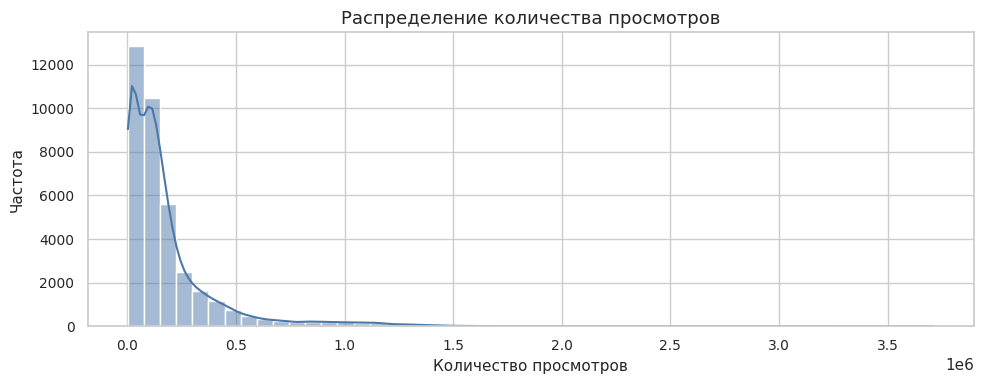

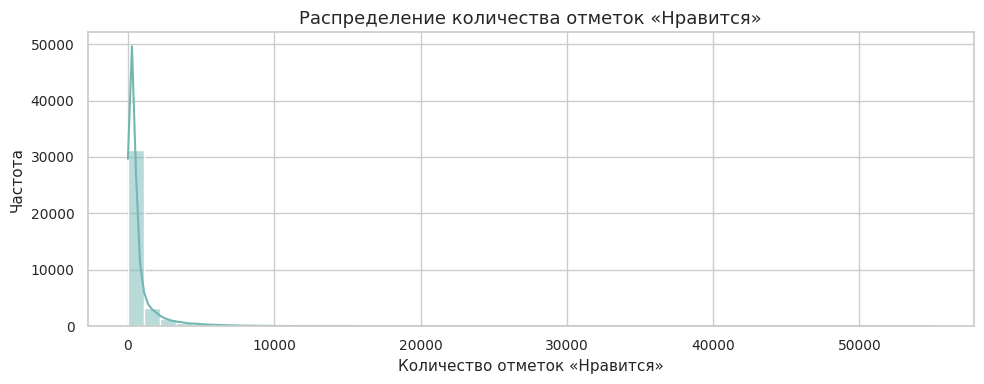

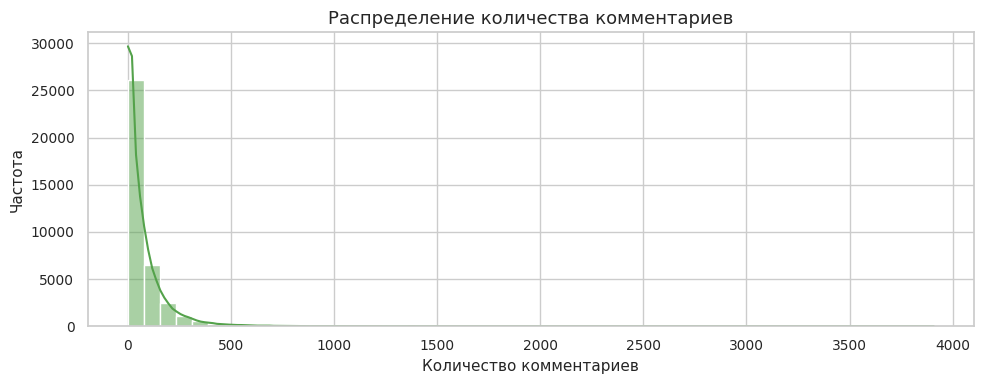

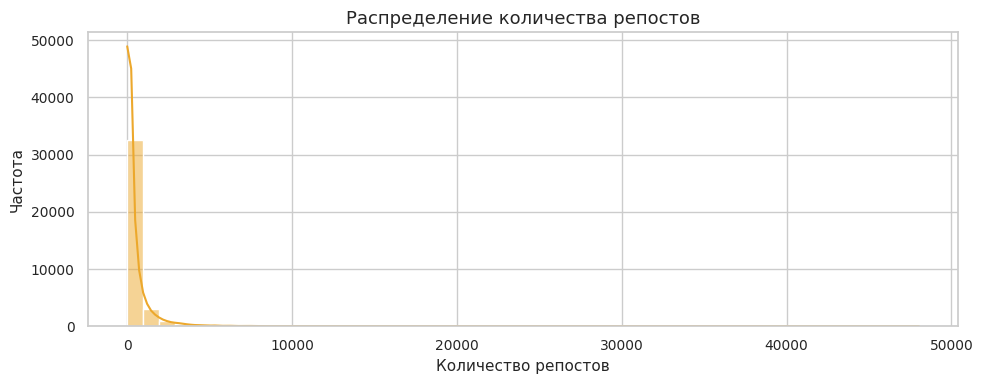

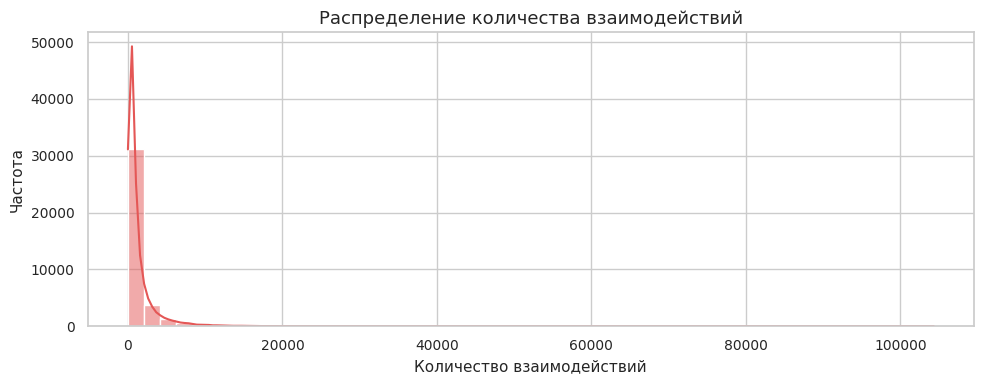

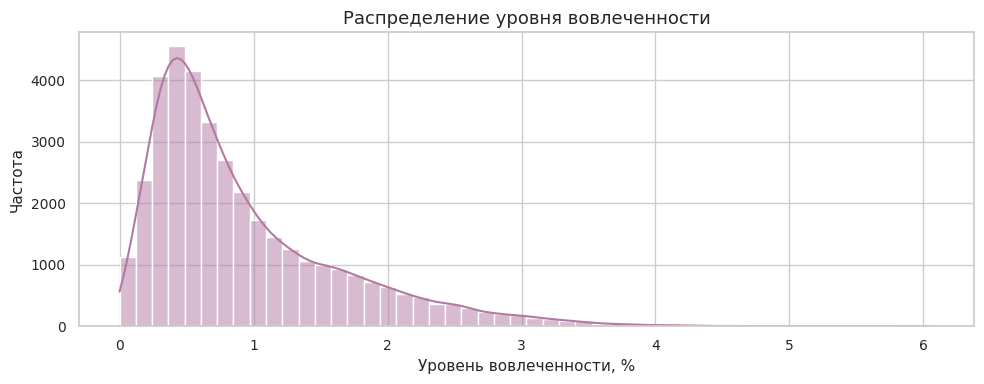

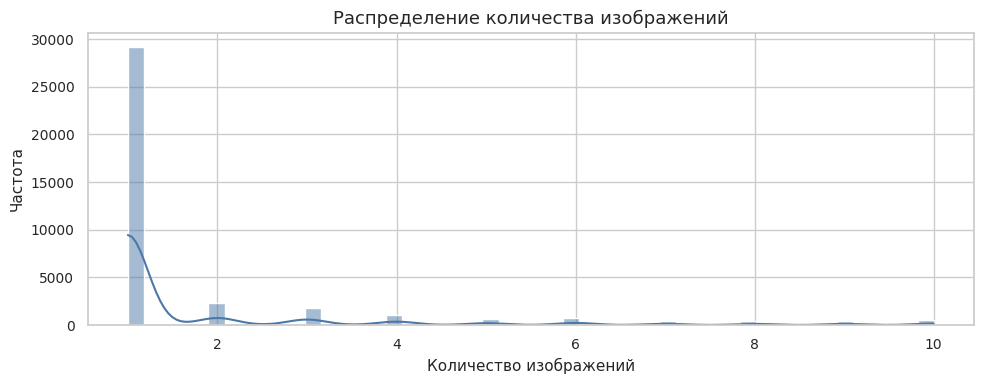

In [19]:
num_cols = ["views", "likes", "comments", "reposts", "engagement", "engagement_rate", "n_photos"]

for col in num_cols:
    plt.figure(figsize=(10, 4))
    sns.set_theme(style="whitegrid", context="notebook")

    if col == "views":
        sns.histplot(data[col], bins=50, kde=True, color="#4C78A8")
        plt.title("Распределение количества просмотров", fontsize=13)
        plt.xlabel("Количество просмотров", fontsize=11)

    elif col == "likes":
        sns.histplot(data[col], bins=50, kde=True, color="#72B7B2")
        plt.title("Распределение количества отметок «Нравится»", fontsize=13)
        plt.xlabel("Количество отметок «Нравится»", fontsize=11)

    elif col == "comments":
        sns.histplot(data[col], bins=50, kde=True, color="#54A24B")
        plt.title("Распределение количества комментариев", fontsize=13)
        plt.xlabel("Количество комментариев", fontsize=11)

    elif col == "reposts":
        sns.histplot(data[col], bins=50, kde=True, color="#ECA82C")
        plt.title("Распределение количества репостов", fontsize=13)
        plt.xlabel("Количество репостов", fontsize=11)

    elif col == "engagement":
        sns.histplot(data[col], bins=50, kde=True, color="#E45756")
        plt.title("Распределение количества взаимодействий", fontsize=13)
        plt.xlabel("Количество взаимодействий", fontsize=11)

    elif col == "engagement_rate":
        sns.histplot(data[col], bins=50, kde=True, color="#B279A2")
        plt.title("Распределение уровня вовлеченности", fontsize=13)
        plt.xlabel("Уровень вовлеченности, %", fontsize=11)

    elif col == "n_photos":
        sns.histplot(data[col], bins=50, kde=True, color="#4C78A8")
        plt.title("Распределение количества изображений", fontsize=13)
        plt.xlabel("Количество изображений", fontsize=11)

    plt.ylabel("Частота", fontsize=11)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.tight_layout()
    plt.show()

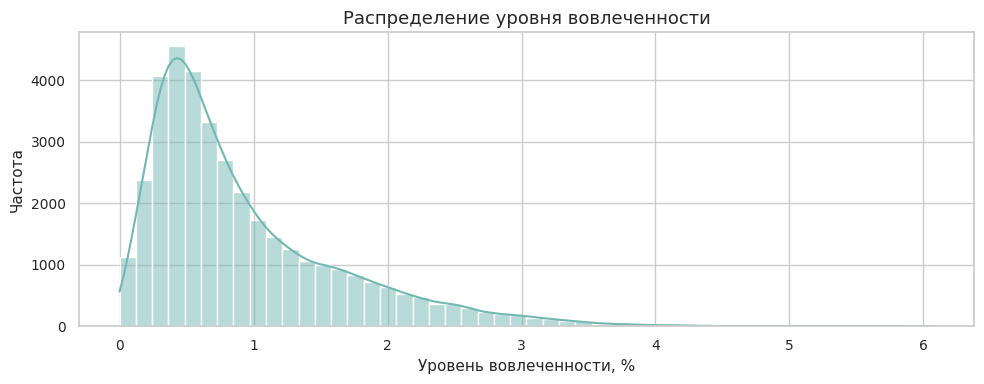

In [20]:
# Распределение уровня вовлеченности
plt.figure(figsize=(10, 4))
sns.set_theme(style="whitegrid", context="notebook")

sns.histplot(data["engagement_rate"], bins=50, kde=True, color="#72B7B2")
plt.title("Распределение уровня вовлеченности", fontsize=13)
plt.xlabel("Уровень вовлеченности, %", fontsize=11)
plt.ylabel("Частота", fontsize=11)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

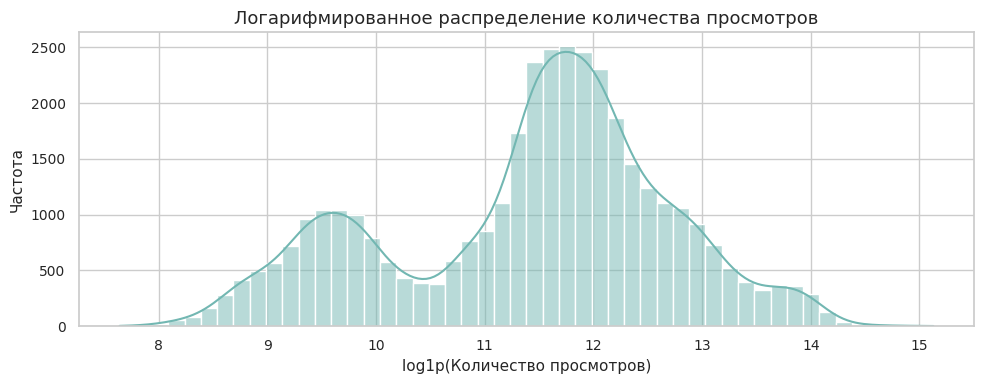

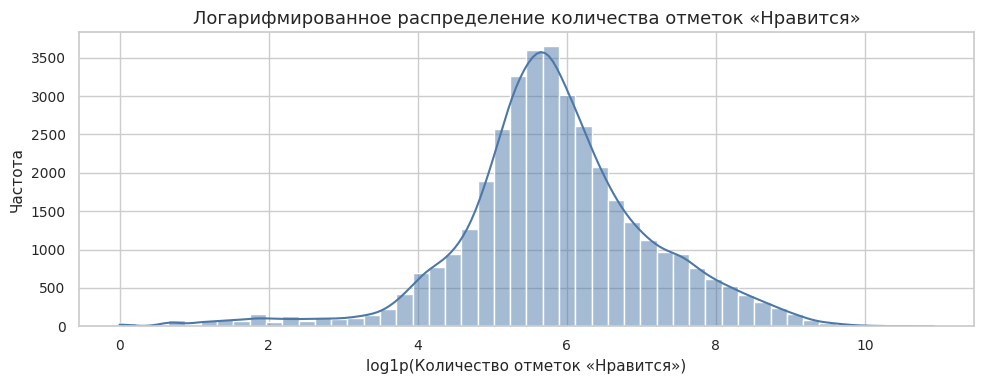

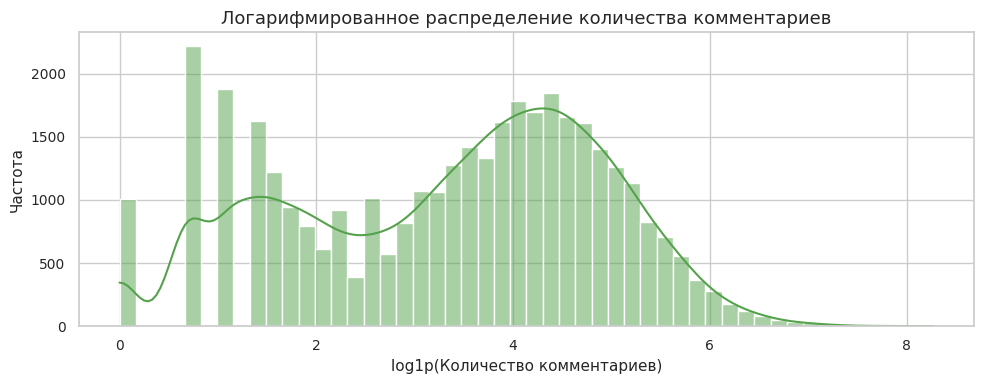

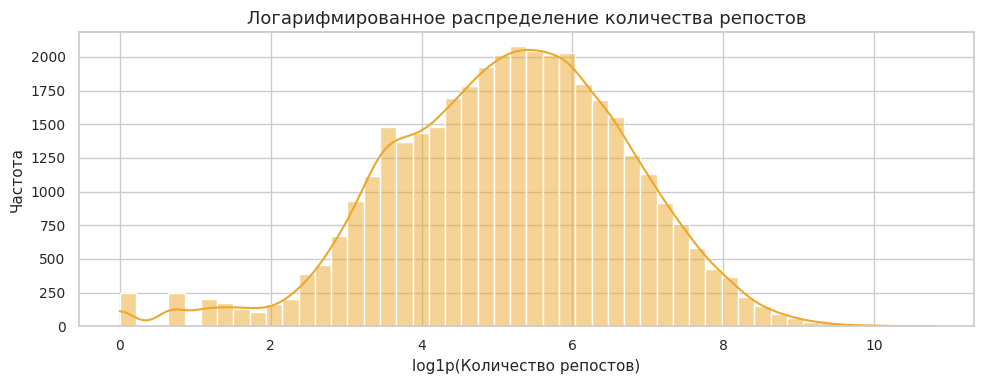

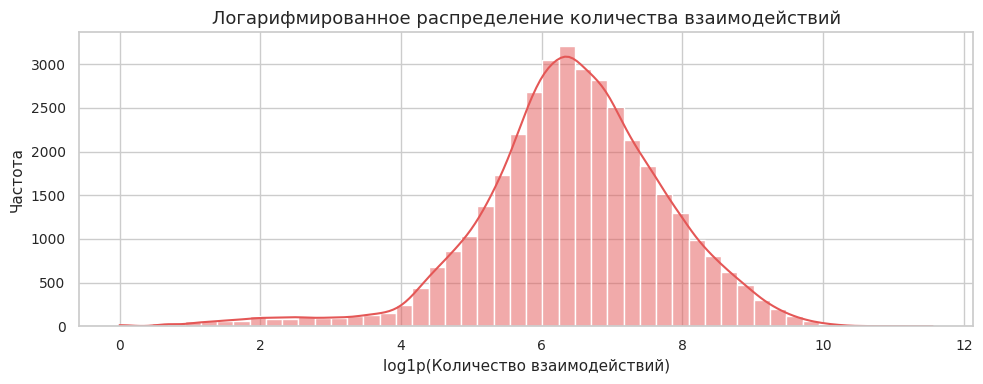

In [21]:
# Логарифмированные распределения
log_cols = ["views", "likes", "comments", "reposts", "engagement"]

for col in log_cols:
    plt.figure(figsize=(10, 4))
    sns.set_theme(style="whitegrid", context="notebook")

    if col == "views":
        sns.histplot(np.log1p(data[col].fillna(0)), bins=50, kde=True, color="#72B7B2")
        plt.title("Логарифмированное распределение количества просмотров", fontsize=13)
        plt.xlabel("log1p(Количество просмотров)", fontsize=11)

    elif col == "likes":
        sns.histplot(np.log1p(data[col].fillna(0)), bins=50, kde=True, color="#4C78A8")
        plt.title("Логарифмированное распределение количества отметок «Нравится»", fontsize=13)
        plt.xlabel("log1p(Количество отметок «Нравится»)", fontsize=11)

    elif col == "comments":
        sns.histplot(np.log1p(data[col].fillna(0)), bins=50, kde=True, color="#54A24B")
        plt.title("Логарифмированное распределение количества комментариев", fontsize=13)
        plt.xlabel("log1p(Количество комментариев)", fontsize=11)

    elif col == "reposts":
        sns.histplot(np.log1p(data[col].fillna(0)), bins=50, kde=True, color="#ECA82C")
        plt.title("Логарифмированное распределение количества репостов", fontsize=13)
        plt.xlabel("log1p(Количество репостов)", fontsize=11)

    elif col == "engagement":
        sns.histplot(np.log1p(data[col].fillna(0)), bins=50, kde=True, color="#E45756")
        plt.title("Логарифмированное распределение количества взаимодействий", fontsize=13)
        plt.xlabel("log1p(Количество взаимодействий)", fontsize=11)

    plt.ylabel("Частота", fontsize=11)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.tight_layout()
    plt.show()

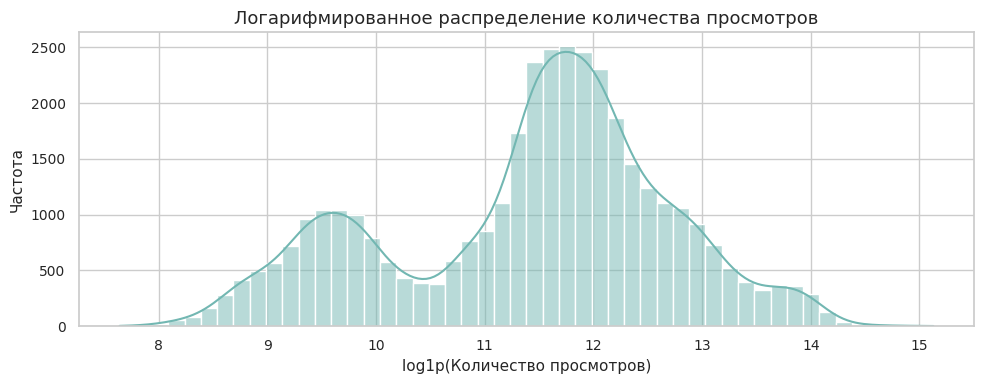

In [22]:
plt.figure(figsize=(10, 4))
sns.set_theme(style="whitegrid", context="notebook")

sns.histplot(np.log1p(data["views"].fillna(0)), bins=50, kde=True, color="#72B7B2")
plt.title("Логарифмированное распределение количества просмотров", fontsize=13)
plt.xlabel("log1p(Количество просмотров)", fontsize=11)
plt.ylabel("Частота", fontsize=11)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

,posts,median_views,mean_views,median_er,mean_er,median_text_len
domain,,,,,,
nrmusicru,7071,291235.0,411042.33,0.55,0.64,302.0
ndnews24,11281,175355.0,217335.98,0.49,0.60,481.0
lentach,7393,104001.0,134917.29,0.65,0.73,289.0
literabook,11680,16875.5,35628.17,1.51,1.54,36.0


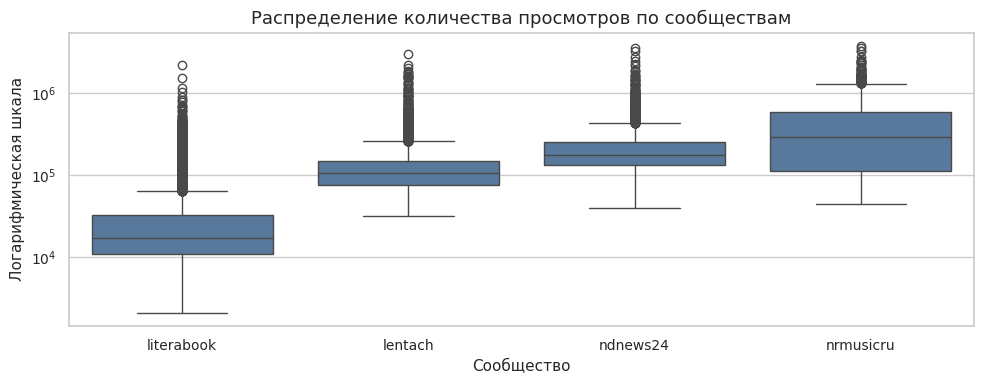

In [23]:
# 9. Сравнение сообществ
domain_stats = data.groupby("domain").agg(
    posts=("post_id", "count"),
    median_views=("views", "median"),
    mean_views=("views", "mean"),
    median_er=("engagement_rate", "median"),
    mean_er=("engagement_rate", "mean"),
    median_text_len=("text", lambda x: x.str.len().median())
).sort_values("median_views", ascending=False)

display(domain_stats.round(2))

plt.figure(figsize=(10, 4))
sns.set_theme(style="whitegrid", context="notebook")
sns.boxplot(data=data, x="domain", y="views", color="#4C78A8")
plt.yscale("log")
plt.title("Распределение количества просмотров по сообществам", fontsize=13)
plt.xlabel("Сообщество", fontsize=11)
plt.ylabel("Логарифмическая шкала", fontsize=11)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

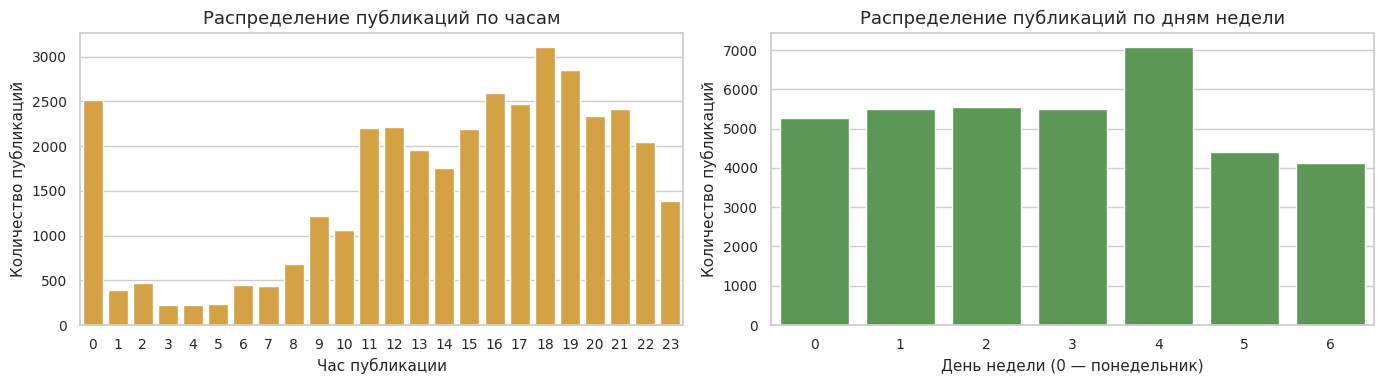

In [24]:
# Время публикации
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.set_theme(style="whitegrid", context="notebook")

sns.countplot(data=data, x="hour", ax=axes[0], color="#ECA82C")
axes[0].set_title("Распределение публикаций по часам", fontsize=13)
axes[0].set_xlabel("Час публикации", fontsize=11)
axes[0].set_ylabel("Количество публикаций", fontsize=11)
axes[0].tick_params(axis="x", labelsize=10)
axes[0].tick_params(axis="y", labelsize=10)

sns.countplot(data=data, x="weekday", ax=axes[1], color="#54A24B")
axes[1].set_title("Распределение публикаций по дням недели", fontsize=13)
axes[1].set_xlabel("День недели (0 — понедельник)", fontsize=11)
axes[1].set_ylabel("Количество публикаций", fontsize=11)
axes[1].tick_params(axis="x", labelsize=10)
axes[1].tick_params(axis="y", labelsize=10)

plt.tight_layout()
plt.show()

,median_views,median_er,posts
hour,,,
0,104332.0,0.65,2519
1,45558.0,0.95,389
2,19895.5,1.54,466
3,22688.0,1.30,226
4,24485.0,1.35,227
5,24396.0,1.33,232
6,19811.5,1.62,444
7,18719.0,1.62,437
8,45445.0,0.88,684


,median_views,median_er,posts
weekday,,,
0,118678.0,0.71,5259
1,119241.0,0.72,5511
2,114400.0,0.71,5547
3,115134.0,0.71,5507
4,107048.0,0.64,7089
5,115491.0,0.70,4397
6,119946.0,0.70,4115


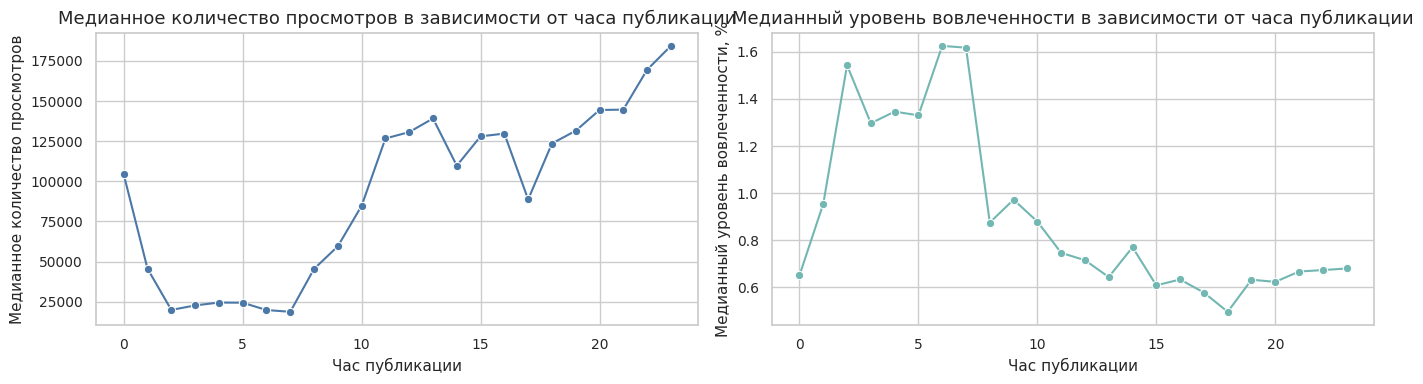

In [25]:
# Влияние времени публикации на просмотры и уровень вовлеченности
hour_stats = data.groupby("hour").agg(
    median_views=("views", "median"),
    median_er=("engagement_rate", "median"),
    posts=("post_id", "count")
)

weekday_stats = data.groupby("weekday").agg(
    median_views=("views", "median"),
    median_er=("engagement_rate", "median"),
    posts=("post_id", "count")
)

display(hour_stats.round(2))
display(weekday_stats.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.set_theme(style="whitegrid", context="notebook")

sns.lineplot(x=hour_stats.index, y=hour_stats["median_views"], marker="o", ax=axes[0], color="#4C78A8")
axes[0].set_title("Медианное количество просмотров в зависимости от часа публикации", fontsize=13)
axes[0].set_xlabel("Час публикации", fontsize=11)
axes[0].set_ylabel("Медианное количество просмотров", fontsize=11)
axes[0].tick_params(axis="x", labelsize=10)
axes[0].tick_params(axis="y", labelsize=10)

sns.lineplot(x=hour_stats.index, y=hour_stats["median_er"], marker="o", ax=axes[1], color="#72B7B2")
axes[1].set_title("Медианный уровень вовлеченности в зависимости от часа публикации", fontsize=13)
axes[1].set_xlabel("Час публикации", fontsize=11)
axes[1].set_ylabel("Медианный уровень вовлеченности, %", fontsize=11)
axes[1].tick_params(axis="x", labelsize=10)
axes[1].tick_params(axis="y", labelsize=10)

plt.tight_layout()
plt.show()

По таблице видно, что посты, опубликованные вечером и поздно вечером, получают больше медианных просмотров: максимум наблюдается в 23:00 — около 185 тыс. просмотров. При этом более высокий median ER характерен для ночных и ранних утренних часов, особенно 02:00–07:00, но там меньше публикаций

In [26]:
# Базовые текстовые фичи
URL_RE = re.compile(r"http[s]?://\S+|www\.\S+")
HASHTAG_RE = re.compile(r"#\w+")
MENTION_RE = re.compile(r"\[club\d+\|.*?\]|\[id\d+\|.*?\]|@\w+")
EMOJI_RE = re.compile(
    "["
    "\U0001F600-\U0001F64F"
    "\U0001F300-\U0001F5FF"
    "\U0001F680-\U0001F6FF"
    "\U0001F1E0-\U0001F1FF"
    "\U00002700-\U000027BF"
    "\U000024C2-\U0001F251"
    "]+", flags=re.UNICODE
)

data["text_len_chars"] = data["text"].str.len()
data["text_len_words"] = data["text"].str.split().str.len()
data["num_exclam"] = data["text"].str.count("!")
data["num_question"] = data["text"].str.count(r"\?")
data["num_dots"] = data["text"].str.count(r"\.")
data["num_commas"] = data["text"].str.count(",")
data["num_lines"] = data["text"].str.count("\n") + 1

data["num_links"] = data["text"].apply(lambda x: len(URL_RE.findall(x)))
data["num_hashtags"] = data["text"].apply(lambda x: len(HASHTAG_RE.findall(x)))
data["num_mentions"] = data["text"].apply(lambda x: len(MENTION_RE.findall(x)))
data["num_emojis"] = data["text"].apply(lambda x: len(EMOJI_RE.findall(x)))
data["caps_ratio"] = data["text"].apply(lambda x: sum(ch.isupper() for ch in x) / max(len(x), 1))
data["is_empty_text"] = (data["text"].str.strip() == "").astype("int8")

text_feature_cols = [
    "text_len_chars", "text_len_words", "num_exclam", "num_question",
    "num_dots", "num_commas", "num_lines", "num_links", "num_hashtags",
    "num_mentions", "num_emojis", "caps_ratio", "is_empty_text"
]

display(data[text_feature_cols].describe().T.round(3))

,count,mean,std,min,25%,50%,75%,max
text_len_chars,37425.0,400.684,658.983,1.0,98.0,310.0,517.0,15731.0
text_len_words,37425.0,57.562,101.224,1.0,14.0,43.0,72.0,2673.0
num_exclam,37425.0,0.147,0.852,0.0,0.0,0.0,0.0,41.0
num_question,37425.0,0.173,1.106,0.0,0.0,0.0,0.0,82.0
num_dots,37425.0,3.967,9.806,0.0,1.0,2.0,4.0,410.0
num_commas,37425.0,4.753,11.155,0.0,0.0,3.0,6.0,479.0
num_lines,37425.0,1.000,0.000,1.0,1.0,1.0,1.0,1.0
num_links,37425.0,0.068,0.418,0.0,0.0,0.0,0.0,34.0
num_hashtags,37425.0,0.057,0.351,0.0,0.0,0.0,0.0,41.0
num_mentions,37425.0,0.593,0.733,0.0,0.0,0.0,1.0,11.0


Верхняя таблица показывает, что тексты постов в среднем имеют умеренную длину, однако присутствуют длинные выбросы. Большинство публикаций почти не содержит ссылок, хэштегов, эмодзи и эмоциональной пунктуации. Пустых текстов после очистки не осталось.

,median_text_len,median_views,median_er,posts
text_len_bin,,,,
0,17.0,18746.0,1.83,3743
1,33.0,18027.5,1.76,3742
2,98.0,123483.0,0.83,3743
3,166.0,126958.0,0.63,3742
4,258.0,140107.0,0.56,3743
5,357.0,135977.0,0.52,3742
6,436.0,142193.5,0.52,3742
7,517.0,149164.0,0.51,3743
8,630.0,156705.0,0.51,3742


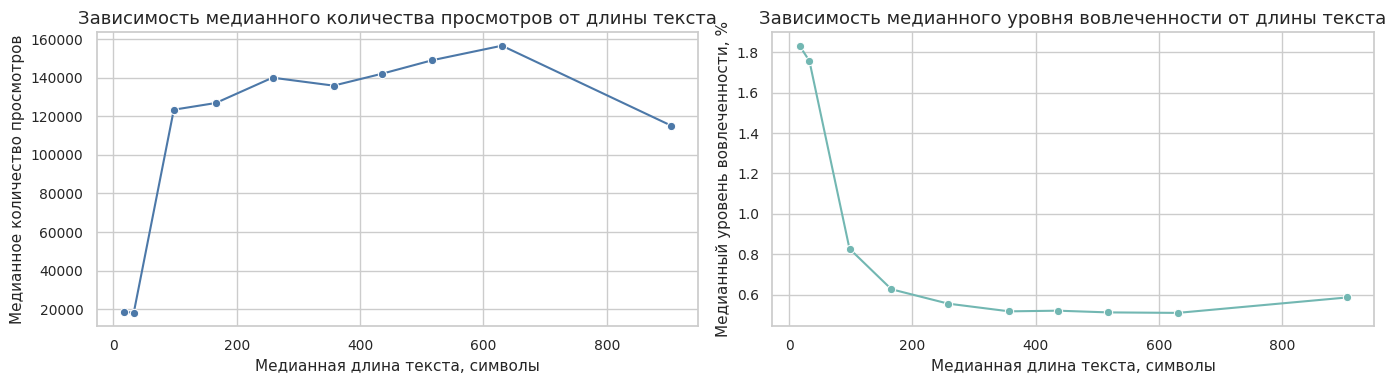

In [27]:
# Связь длины текста с просмотрами и уровнем вовлеченности
data["text_len_bin"] = pd.qcut(
    data["text_len_chars"].rank(method="first"),
    q=10,
    labels=False
)

bin_stats = data.groupby("text_len_bin").agg(
    median_text_len=("text_len_chars", "median"),
    median_views=("views", "median"),
    median_er=("engagement_rate", "median"),
    posts=("post_id", "count")
)

display(bin_stats.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.set_theme(style="whitegrid", context="notebook")

sns.lineplot(data=bin_stats, x="median_text_len", y="median_views", marker="o", ax=axes[0], color="#4C78A8")
axes[0].set_title("Зависимость медианного количества просмотров от длины текста", fontsize=13)
axes[0].set_xlabel("Медианная длина текста, символы", fontsize=11)
axes[0].set_ylabel("Медианное количество просмотров", fontsize=11)
axes[0].tick_params(axis="x", labelsize=10)
axes[0].tick_params(axis="y", labelsize=10)

sns.lineplot(data=bin_stats, x="median_text_len", y="median_er", marker="o", ax=axes[1], color="#72B7B2")
axes[1].set_title("Зависимость медианного уровня вовлеченности от длины текста", fontsize=13)
axes[1].set_xlabel("Медианная длина текста, символы", fontsize=11)
axes[1].set_ylabel("Медианный уровень вовлеченности, %", fontsize=11)
axes[1].tick_params(axis="x", labelsize=10)
axes[1].tick_params(axis="y", labelsize=10)

plt.tight_layout()
plt.show()

По таблице видно, что короткие тексты имеют более высокий engagement rate, но меньше просмотров. Более длинные тексты, начиная примерно с 90 символов, получают значительно больше медианных просмотров, однако их median ER ниже. Это указывает на различие между абсолютной популярностью поста и относительной вовлечённостью аудитории.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,word,count
0,россии,4340
1,рублей,2892
2,сша,2656
3,жизни,2652
4,человек,2288
5,заявил,2257
6,жизнь,2253
7,тысяч,1671
8,люди,1584
9,людей,1493


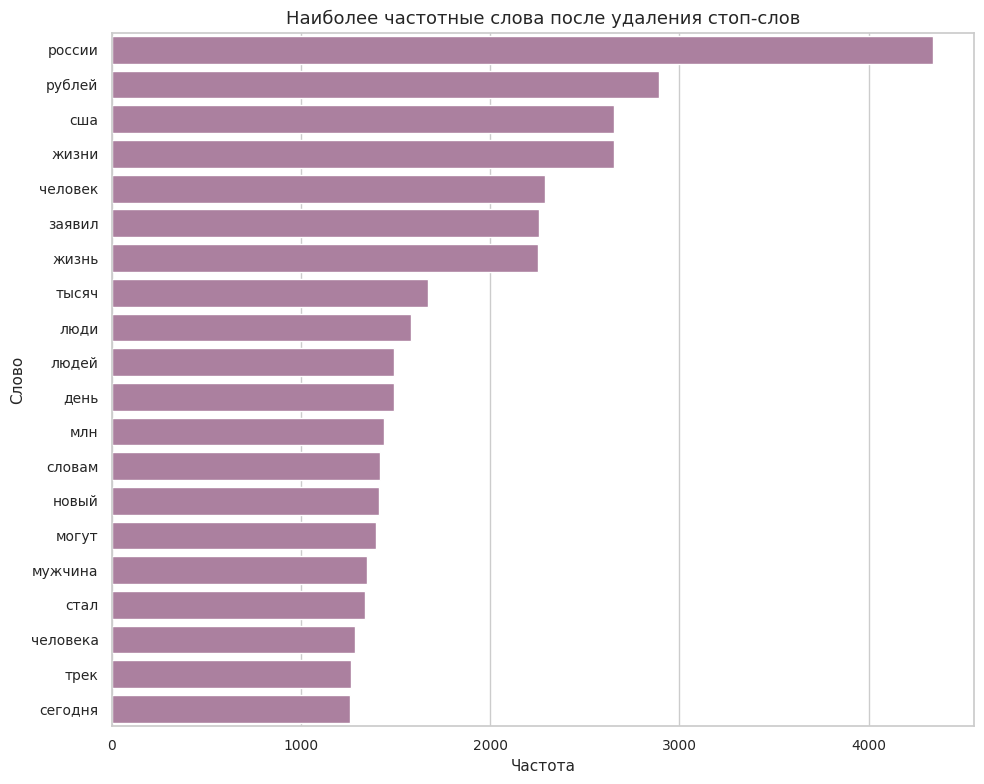

In [28]:
from collections import Counter
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")

russian_stopwords = set(stopwords.words("russian"))

custom_stopwords = {
    "это", "также", "который", "которые", "которая", "которое",
    "просто", "очень", "своей", "свой", "свои", "свою",
    "нужно", "будут", "года", "году", "лет", "время",
    "club", "id", "https", "http", "www", "com", "ru",
    "nrmusicru", "ndnews24", "literabook", "lentach"
}

all_stopwords = russian_stopwords | custom_stopwords

URL_RE = re.compile(r"http[s]?://\S+|www\.\S+")
MENTION_RE = re.compile(r"\[club\d+\|.*?\]|\[id\d+\|.*?\]|@\w+")
HASHTAG_RE = re.compile(r"#\w+")


def simple_tokenize_without_stopwords(text):
    text = str(text).lower()
    text = re.sub(r"ё", "е", text)
    text = URL_RE.sub(" ", text)
    text = MENTION_RE.sub(" ", text)
    text = HASHTAG_RE.sub(" ", text)
    tokens = re.findall(r"[а-яa-z]{3,}", text)

    tokens = [
        token for token in tokens
        if token not in all_stopwords
    ]

    return tokens


all_tokens_no_stopwords = []

for text in data["text"].fillna(""):
    all_tokens_no_stopwords.extend(simple_tokenize_without_stopwords(text))


word_freq_no_stopwords = pd.DataFrame(
    Counter(all_tokens_no_stopwords).most_common(50),
    columns=["word", "count"]
)

display(word_freq_no_stopwords.head(30))

plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid", context="notebook")
sns.barplot(
    data=word_freq_no_stopwords.head(20),
    y="word",
    x="count",
    color="#B279A2"
)
plt.title("Наиболее частотные слова после удаления стоп-слов", fontsize=13)
plt.xlabel("Частота", fontsize=11)
plt.ylabel("Слово", fontsize=11)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

В топе преобладают слова новостной, социальной и финансовой тематики. Часто встречаются упоминания стран, людей, денежных сумм и событий, а также отдельные музыкальные термины, например «трек» и «альбом».

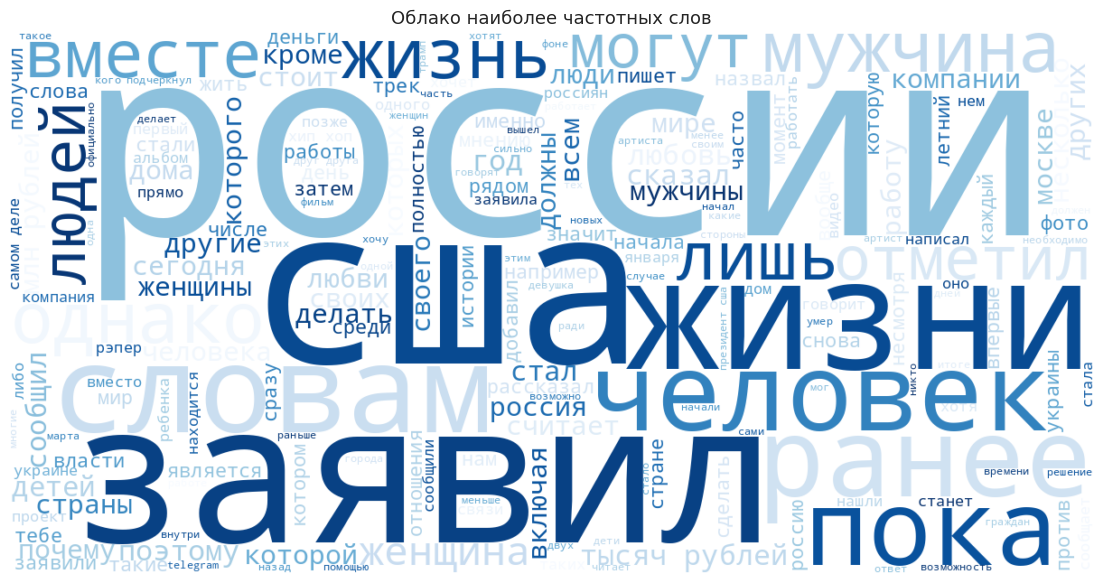

In [29]:
from wordcloud import WordCloud

text_for_cloud = " ".join(all_tokens_no_stopwords)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    colormap="Blues"
).generate(text_for_cloud)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Облако наиболее частотных слов", fontsize=13)
plt.tight_layout()
plt.show()

In [30]:
def filter_out_iqr(group: pd.DataFrame) -> pd.DataFrame:
    q1 = group["views"].quantile(0.25)
    q3 = group["views"].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return group[(group["views"] >= lower) & (group["views"] <= upper)]

In [31]:
df_filtered = df.groupby('domain', group_keys=False).apply(filter_out_iqr)

In [32]:
df_filtered.shape

(36335, 22)

###Разработка признаков


In [33]:
def make_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    dt = pd.to_datetime(df["dt_msk"], errors="coerce")

    df["hour"] = dt.dt.hour.fillna(0).astype("int16")
    df["weekday"] = dt.dt.weekday.fillna(0).astype("int16")
    df["month"] = dt.dt.month.fillna(0).astype("int16")
    df["day"] = dt.dt.day.fillna(0).astype("int16")

    df["is_weekend"] = (df["weekday"] >= 5).astype("int8")
    df["is_workday"] = (df["weekday"] < 5).astype("int8")
    df["is_friday"] = (df["weekday"] == 4).astype("int8")

    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    df["weekday_sin"] = np.sin(2 * np.pi * df["weekday"] / 7)
    df["weekday_cos"] = np.cos(2 * np.pi * df["weekday"] / 7)

    df["n_photos"] = df["n_photos"].fillna(0).astype("int16")

    txt = df["text"].fillna("").astype(str)

    df["text_len_chars"] = txt.str.len().astype("int32")
    df["text_len_words"] = txt.str.split().str.len().fillna(0).astype("int32")
    df["num_lines"] = (txt.str.count("\n") + 1).astype("int16")

    df["num_exclam"] = txt.str.count("!").astype("int16")
    df["num_question"] = txt.str.count(r"\?").astype("int16")
    df["num_dots"] = txt.str.count(r"\.").astype("int16")
    df["num_commas"] = txt.str.count(",").astype("int16")
    df["num_colons"] = txt.str.count(":").astype("int16")

    df["num_hashtags"] = txt.str.count("#").astype("int16")
    df["num_links"] = (txt.str.count("http") + txt.str.count("vk.cc")).astype("int16")
    df["has_mention"] = txt.str.contains(r"\[club|\[id|@", regex=True, na=False).astype(
        "int8"
    )
    df["num_emojis"] = txt.str.count(r"[\U0001F300-\U0001FAFF]").astype("int16")

    letters = txt.str.findall(r"[A-Za-zА-Яа-яЁё]")
    caps = txt.str.findall(r"[A-ZА-ЯЁ]")
    df["caps_ratio"] = (
        (caps.str.len() / letters.str.len().replace(0, np.nan))
        .fillna(0.0)
        .astype("float32")
    )
    words = txt.str.findall(r"\w+", flags=re.UNICODE)
    digits = txt.str.findall(r"\d")
    caps_words = txt.str.findall(r"\b[A-ZА-ЯЁ]{2,}\b")

    df["unique_words_count"] = words.apply(
        lambda x: len(set(w.lower() for w in x))
    ).astype("int32")

    df["unique_words_ratio"] = (
        (df["unique_words_count"] / df["text_len_words"].replace(0, np.nan))
        .fillna(0.0)
        .astype("float32")
    )

    df["avg_word_len"] = words.apply(
        lambda x: np.mean([len(w) for w in x]) if len(x) else 0
    ).astype("float32")

    df["long_words_count"] = words.apply(lambda x: sum(len(w) >= 8 for w in x)).astype(
        "int16"
    )

    df["digit_count"] = digits.str.len().astype("int16")
    df["digit_ratio"] = (
        (df["digit_count"] / df["text_len_chars"].replace(0, np.nan))
        .fillna(0.0)
        .astype("float32")
    )

    df["uppercase_words_count"] = caps_words.str.len().astype("int16")

    sentence_count = txt.str.count(r"[.!?]+")
    df["sentence_count"] = np.where(
        df["text_len_chars"] > 0,
        sentence_count + 1,
        0,
    ).astype("int16")

    df["avg_sentence_len_words"] = (
        (df["text_len_words"] / df["sentence_count"].replace(0, np.nan))
        .fillna(0.0)
        .astype("float32")
    )

    df["ellipsis_count"] = txt.str.count(r"\.\.\.|…").astype("int16")
    df["repeat_punct_count"] = txt.str.count(r"[!?]{2,}").astype("int16")

    df["has_url"] = txt.str.contains(r"http|www|vk\.cc", regex=True, na=False).astype(
        "int8"
    )
    df["has_number"] = txt.str.contains(r"\d", regex=True, na=False).astype("int8")
    df["has_price"] = txt.str.contains(
        r"\d+\s?(₽|руб|р\b)|скидк|цена|бесплатно|акция",
        regex=True,
        case=False,
        na=False,
    ).astype("int8")

    df["starts_with_question"] = txt.str.match(
        r"^\s*[^a-zA-ZА-Яа-яЁё0-9]*.*\?", na=False
    ).astype("int8")
    df["starts_with_number"] = txt.str.match(r"^\s*\d", na=False).astype("int8")
    df["starts_with_emoji"] = txt.str.match(
        r"^\s*[\U0001F300-\U0001FAFF]", na=False
    ).astype("int8")

    cta_pattern = (
        r"пиши|смотри|читай|успей|переходи|жми|сохрани|подпишись|голосуй|оцени"
    )
    urgency_pattern = r"сегодня|сейчас|срочно|только сегодня|последний шанс|успей"

    df["has_call_to_action"] = txt.str.contains(
        cta_pattern,
        regex=True,
        case=False,
        na=False,
    ).astype("int8")

    df["has_urgency"] = txt.str.contains(
        urgency_pattern,
        regex=True,
        case=False,
        na=False,
    ).astype("int8")

    df["part_of_day"] = pd.cut(
        df["hour"],
        bins=[-1, 5, 11, 17, 23],
        labels=["night", "morning", "afternoon", "evening"],
    )

    df["text_len_bin"] = pd.cut(
        df["text_len_words"],
        bins=[-1, 5, 15, 30, 60, 10**9],
        labels=["very_short", "short", "medium", "long", "very_long"],
    )

    df["hour_weekday"] = df["hour"].astype(str) + "_" + df["weekday"].astype(str)
    df["domain_weekday"] = (
        df["domain"].fillna("unknown").astype(str) + "_" + df["weekday"].astype(str)
    )
    df["domain_part_of_day"] = (
        df["domain"].fillna("unknown").astype(str) + "_" + df["part_of_day"].astype(str)
    )
    df["weekend_hour"] = df["is_weekend"].astype(str) + "_" + df["hour"].astype(str)

    return df

In [34]:
df_with_features =  make_features(df_filtered)

In [35]:
df_with_features.head()

,domain,owner_id,post_id,post_key,from_id,dt_msk,edited_dt_msk,text,views,likes,comments,reposts,reactions_total,is_pinned,marked_as_ads,is_donut,post_source_type,post_type,n_photos,cover_photo_url,all_photo_urls,post_url,hour,weekday,month,day,is_weekend,is_workday,is_friday,hour_sin,hour_cos,weekday_sin,weekday_cos,text_len_chars,text_len_words,num_lines,num_exclam,num_question,num_dots,num_commas,num_colons,num_hashtags,num_links,has_mention,num_emojis,caps_ratio,unique_words_count,unique_words_ratio,avg_word_len,long_words_count,digit_count,digit_ratio,uppercase_words_count,sentence_count,avg_sentence_len_words,ellipsis_count,repeat_punct_count,has_url,has_number,has_price,starts_with_question,starts_with_number,starts_with_emoji,has_call_to_action,has_urgency,part_of_day,text_len_bin,hour_weekday,domain_weekday,domain_part_of_day,weekend_hour
13906,lentach,-29534144,24937205,-29534144_24937205,-29534144,2026-04-02 11:19:31+03:00,NaN,Минцифры собирается сократить число мелких про...,180070,727,179,475,727.0,0,0,0,api,post,1,https://sun1-28.userapi.com/s/v1/ig2/62INnj8jY...,"[""https://sun1-28.userapi.com/s/v1/ig2/62INnj8...",https://vk.com/wall-29534144_24937205,11,3,4,2,0,1,0,0.258819,-9.659258e-01,0.433884,-0.900969,507,71,5,0,0,3,5,0,0,0,0,0,0.019139,65,0.915493,5.957747,26,5,0.009862,1,4,17.750000,0,0,0,1,0,0,0,0,0,0,morning,very_long,11_3,lentach_3,lentach_morning,0_11
13907,lentach,-29534144,24937094,-29534144_24937094,-29534144,2026-04-02 10:42:51+03:00,NaN,NASA впервые за 54 года отправила астронавтов ...,130481,587,277,221,587.0,0,0,0,api,post,1,https://sun1-95.userapi.com/s/v1/ig2/XW7iXo9-g...,"[""https://sun1-95.userapi.com/s/v1/ig2/XW7iXo9...",https://vk.com/wall-29534144_24937094,10,3,4,2,0,1,0,0.500000,-8.660254e-01,0.433884,-0.900969,521,80,5,0,0,5,2,0,0,0,0,0,0.060680,71,0.887500,5.108434,19,12,0.023033,3,6,13.333333,0,0,0,1,0,0,0,0,0,0,morning,very_long,10_3,lentach_3,lentach_morning,0_10
13909,lentach,-29534144,24936809,-29534144_24936809,-29534144,2026-04-01 21:48:33+03:00,NaN,Воздух и небо стали красными на острове Крит в...,99564,758,18,281,758.0,0,0,0,api,post,4,https://sun1-84.userapi.com/s/v1/ig2/5JWyXH1Al...,"[""https://sun1-84.userapi.com/s/v1/ig2/5JWyXH1...",https://vk.com/wall-29534144_24936809,21,2,4,1,0,1,0,-0.707107,7.071068e-01,0.974928,-0.222521,86,16,1,0,0,0,0,0,0,0,0,0,0.043478,16,1.000000,4.312500,2,0,0.000000,0,1,16.000000,0,0,0,0,0,0,0,0,0,0,evening,medium,21_2,lentach_2,lentach_evening,0_21
13910,lentach,-29534144,24936731,-29534144_24936731,-29534144,2026-04-01 20:17:47+03:00,NaN,"В Италии женщина умерла после того, как её раз...",160950,594,40,869,594.0,0,0,0,api,post,1,https://sun1-14.userapi.com/s/v1/ig2/SMezKcSQV...,"[""https://sun1-14.userapi.com/s/v1/ig2/SMezKcS...",https://vk.com/wall-29534144_24936731,20,2,4,1,0,1,0,-0.866025,5.000000e-01,0.974928,-0.222521,268,38,3,0,0,1,4,0,0,0,0,0,0.013514,37,0.973684,5.743590,12,2,0.007463,0,2,19.000000,0,0,0,1,0,0,0,0,0,0,evening,long,20_2,lentach_2,lentach_evening,0_20
13911,lentach,-29534144,24936681,-29534144_24936681,-29534144,2026-04-01 18:44:36+03:00,NaN,Сегодня Apple исполнилось 50 лет.\n\nКомпания ...,66011,350,51,62,350.0,0,0,0,api,post,1,https://sun1-84.userapi.com/s/v1/ig2/TKfAVLMy0...,"[""https://sun1-84.userapi.com/s/v1/ig2/TKfAVLM...",https://vk.com/wall-29534144_24936681,18,2,4,1,0,1,0,-1.000000,-1.836970e-16,0.974928,-0.222521,127,19,3,0,0,1,1,0,0,0,0,0,0.090909,18,0.947368,5.578948,5,7,0.055118,0,2,9.500000,0,0,0,1,0,0,0,0,0,1,evening,medium,18_2,lentach_2,lentach_evening,0_18


In [36]:
drop_cols = [
        "post_type",
        "is_donut",
        "post_url",
        "marked_as_ads",
        "post_source_type",
        "views",
        "likes",
        "comments",
        "reposts",
        "reactions_total",
        "owner_id",
        "post_key",
        "from_id",
        "date_unix",
        "cover_photo_url",
        "all_photo_urls",
        "edited_dt_msk"
    ]
df_with_features = df_with_features.drop(columns=[c for c in drop_cols if c in df.columns])

In [37]:
df_with_features

,domain,post_id,dt_msk,text,is_pinned,n_photos,hour,weekday,month,day,is_weekend,is_workday,is_friday,hour_sin,hour_cos,weekday_sin,weekday_cos,text_len_chars,text_len_words,num_lines,num_exclam,num_question,num_dots,num_commas,num_colons,num_hashtags,num_links,has_mention,num_emojis,caps_ratio,unique_words_count,unique_words_ratio,avg_word_len,long_words_count,digit_count,digit_ratio,uppercase_words_count,sentence_count,avg_sentence_len_words,ellipsis_count,repeat_punct_count,has_url,has_number,has_price,starts_with_question,starts_with_number,starts_with_emoji,has_call_to_action,has_urgency,part_of_day,text_len_bin,hour_weekday,domain_weekday,domain_part_of_day,weekend_hour
13906,lentach,24937205,2026-04-02 11:19:31+03:00,Минцифры собирается сократить число мелких про...,0,1,11,3,4,2,0,1,0,0.258819,-9.659258e-01,0.433884,-0.900969,507,71,5,0,0,3,5,0,0,0,0,0,0.019139,65,0.915493,5.957747,26,5,0.009862,1,4,17.750000,0,0,0,1,0,0,0,0,0,0,morning,very_long,11_3,lentach_3,lentach_morning,0_11
13907,lentach,24937094,2026-04-02 10:42:51+03:00,NASA впервые за 54 года отправила астронавтов ...,0,1,10,3,4,2,0,1,0,0.500000,-8.660254e-01,0.433884,-0.900969,521,80,5,0,0,5,2,0,0,0,0,0,0.060680,71,0.887500,5.108434,19,12,0.023033,3,6,13.333333,0,0,0,1,0,0,0,0,0,0,morning,very_long,10_3,lentach_3,lentach_morning,0_10
13909,lentach,24936809,2026-04-01 21:48:33+03:00,Воздух и небо стали красными на острове Крит в...,0,4,21,2,4,1,0,1,0,-0.707107,7.071068e-01,0.974928,-0.222521,86,16,1,0,0,0,0,0,0,0,0,0,0.043478,16,1.000000,4.312500,2,0,0.000000,0,1,16.000000,0,0,0,0,0,0,0,0,0,0,evening,medium,21_2,lentach_2,lentach_evening,0_21
13910,lentach,24936731,2026-04-01 20:17:47+03:00,"В Италии женщина умерла после того, как её раз...",0,1,20,2,4,1,0,1,0,-0.866025,5.000000e-01,0.974928,-0.222521,268,38,3,0,0,1,4,0,0,0,0,0,0.013514,37,0.973684,5.743590,12,2,0.007463,0,2,19.000000,0,0,0,1,0,0,0,0,0,0,evening,long,20_2,lentach_2,lentach_evening,0_20
13911,lentach,24936681,2026-04-01 18:44:36+03:00,Сегодня Apple исполнилось 50 лет.\n\nКомпания ...,0,1,18,2,4,1,0,1,0,-1.000000,-1.836970e-16,0.974928,-0.222521,127,19,3,0,0,1,1,0,0,0,0,0,0.090909,18,0.947368,5.578948,5,7,0.055118,0,2,9.500000,0,0,0,1,0,0,0,0,0,1,evening,medium,18_2,lentach_2,lentach_evening,0_18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39685,nrmusicru,18315862,2024-01-01 18:35:00+03:00,"[club221930245|MALO1MALO] — ""Заберём""\n\nРэпер...",0,1,18,0,1,1,0,1,0,-1.000000,-1.836970e-16,0.000000,1.000000,161,19,3,0,0,1,0,0,0,0,1,0,0.163934,17,0.894737,7.000000,7,11,0.068323,0,2,9.500000,0,0,0,1,0,0,0,0,0,0,evening,medium,18_0,nrmusicru_0,nrmusicru_evening,0_18
39686,nrmusicru,18315782,2024-01-01 17:35:00+03:00,"[club166960170|5score] — ""Так темно""\n\nЕще од...",0,1,17,0,1,1,0,1,0,-0.965926,-2.588190e-01,0.000000,1.000000,401,61,5,0,0,5,3,0,0,0,1,0,0.026490,50,0.819672,5.233333,10,12,0.029925,0,6,10.166667,0,0,0,1,0,0,0,0,0,0,afternoon,very_long,17_0,nrmusicru_0,nrmusicru_afternoon,0_17
39687,nrmusicru,18315729,2024-01-01 17:05:00+03:00,"Сериалы, которые стоит посмотреть, если вам по...",0,7,17,0,1,1,0,1,0,-0.965926,-2.588190e-01,0.000000,1.000000,85,9,1,0,0,0,2,0,0,0,1,0,0.032258,10,1.111111,7.000000,3,8,0.094118,0,1,9.000000,0,0,0,1,0,0,0,0,0,0,afternoon,short,17_0,nrmusicru_0,nrmusicru_afternoon,0_17
39688,nrmusicru,18315625,2024-01-01 15:03:57+03:00,"Есть вещи, которые в этом мире неизменны",0,10,15,0,1,1,0,1,0,-0.707107,-7.071068e-01,0.000000,1.000000,40,7,1,0,0,0,1,0,0,0,0,0,0.030303,7,1.000000,4.714286,1,0,0.000000,0,1,7.000000,0,0,0,0,0,0,0,0,0,0,afternoon,short,15_0,nrmusicru_0,nrmusicru_afternoon,0_15


In [38]:
constant_cols = [col for col in df_with_features.columns if df_with_features[col].nunique(dropna=False) == 1]

print("Константные признаки:")
print(constant_cols)

Константные признаки:
['is_pinned']


In [39]:
for col in df_with_features.columns:
    top_freq = df_with_features[col].value_counts(dropna=False, normalize=True).iloc[0]
    if top_freq > 0.95:
        print(col, round(top_freq, 3))

is_pinned 1.0
repeat_punct_count 0.997
has_price 0.971
starts_with_question 0.972
starts_with_number 0.988
starts_with_emoji 0.997
has_call_to_action 0.954
